# Lab 3 — Semantic Search

Run this notebook top to bottom as you build out `embeddings.py` and `search.py` in this same folder. See `Lab3_Instructions.md` for what belongs in each step.

This notebook is just a shell: it imports your functions and gives you a place to call them, but the corpus, example queries, and visualization are yours to write.

In [2]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import os
import json

from search import load_documents, build_embedding_matrix, search , visualize_pca , pca_via_svd

## Step 1-2: Load your corpus and fetch embeddings

In [3]:
# TODO: load_documents("documents.json") and build_embedding_matrix(documents)
from search import load_documents, build_embedding_matrix

# Load documents
documents = load_documents("documents.json")

# Build/load cached embeddings
embedding_matrix = build_embedding_matrix(documents)

print("Number of documents:", len(documents))
print("Embedding matrix shape:", embedding_matrix.shape)

# Start in offline mode (the default) while you're building - switch to the real
# API once your pipeline works end to end.

Loaded embeddings from cache.
Number of documents: 24
Embedding matrix shape: (24, 1024)


## Step 3: Run a few example search queries

In [8]:
# TODO: call search(query, embedding_matrix, documents, top_k=3) with at least two
# different queries and print the results
results = search(
    "How does one bake bread?",
    embedding_matrix,
    documents,
    top_k=3
)

for doc, score in results:
    print(f"[{score:.3f}] ({doc['topic']}) {doc['text']}")

print(" --------------------------- ")

results = search(
    "How do you score a goal?",
    embedding_matrix,
    documents,
    top_k=3
)

for doc, score in results:
    print(f"[{score:.3f}] ({doc['topic']}) {doc['text']}")

[0.422] (cooking) Baking bread requires yeast to ferment the dough and create air pockets.
[0.286] (cooking) Simmering soup over low heat allows flavors to blend gradually.
[0.265] (cooking) Boiling pasta in well-salted water improves its flavor and texture.
 --------------------------- 
[0.440] (sports) Football is played between two teams that compete to score goals.
[0.427] (sports) Basketball players score points by shooting the ball through the opponent's hoop.
[0.324] (sports) Tennis matches are won by earning enough sets according to the tournament rules.


## Step 4: Visualize the embedding space with PCA

Loaded embeddings from cache.


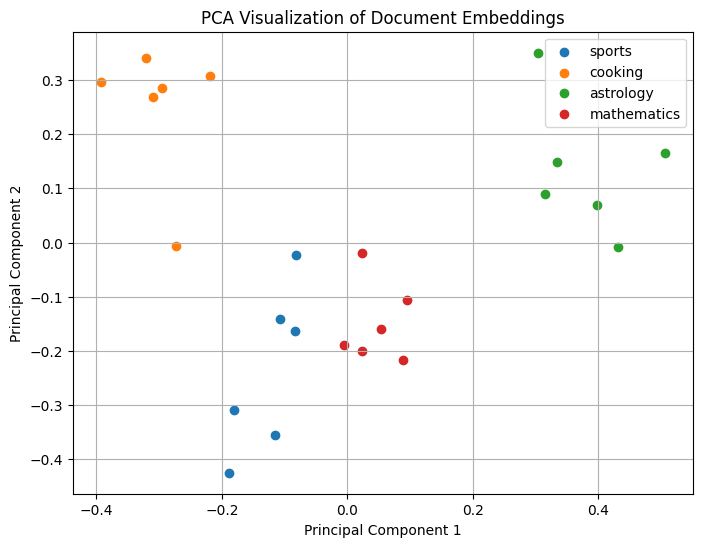

In [10]:
# TODO: reuse your Lab 2 PCA-via-SVD function (extended to 2 components) to project
# the embedding matrix down to 2D, then scatter-plot it colored by topic
documents = load_documents("documents.json")

embedding_matrix = build_embedding_matrix(documents)

visualize_pca(embedding_matrix, documents)

The scatter plot shows four visibly distinct clusters corresponding to the four document topics, confirming that the embedding space captures meaningful semantic structure.

Astrology (green) and cooking (orange) separate most cleanly, occupying opposite regions of the plot along Principal Component 1 — astrology sits in the positive-PC1 region, cooking in the negative-PC1 region, with no overlap between the two groups.

Mathematics (red) and sports (blue) form their own distinct clusters as well, though they sit closer to each other along Principal Component 2 than the other topic pairs do — both occupy the lower half of the plot, with sports extending further down and mathematics sitting slightly above it. This is a reasonable result: math and sports documents are more likely to share incidental vocabulary (numbers, scoring, measurement) than, say, cooking and astrology, so some proximity between them in the embedding space is expected.